<a href="https://colab.research.google.com/github/ChungViTin/TH_DeepLearning/blob/main/TH_DeepLearning_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Nạp thư viện

In [ ]:
#install required libraries
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D, MaxPooling2D, Flatten, Dense, Dropout

# Note: KerasClassifier has moved to the 'scikeras' library.
# If you need to use it, run: !pip install scikeras
# and then: from scikeras.wrappers import KerasClassifier
# For now, I will comment out the problematic import to allow the rest of the code to run.
# from keras.wrappers.scikit_learn import KerasClassifier

#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

###Xử lý dữ liệu

In [ ]:
#tải bộ mnist fashion dataset
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [ ]:
#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#feature scaling
minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


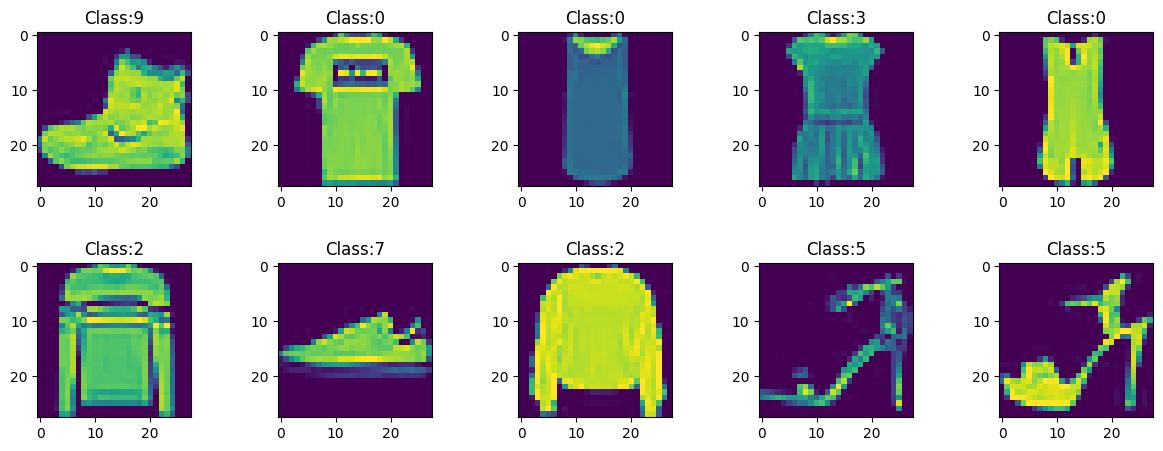

In [ ]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
#initial ANN model
fashion_model = Sequential()

#add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8210 - loss: 0.5058 - val_accuracy: 0.8565 - val_loss: 0.4173
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8631 - loss: 0.3754 - val_accuracy: 0.8653 - val_loss: 0.3697
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8779 - loss: 0.3331 - val_accuracy: 0.8757 - val_loss: 0.3353
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8856 - loss: 0.3081 - val_accuracy: 0.8727 - val_loss: 0.3496
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8931 - loss: 0.2906 - val_accuracy: 0.8735 - val_loss: 0.3478
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8973 - loss: 0.2753 - val_accuracy: 0.8768 - val_loss: 0.3368
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9045 - loss: 0.2595 - val_accuracy: 0.8798 - val_loss: 0.3312
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9067 - loss: 0.25

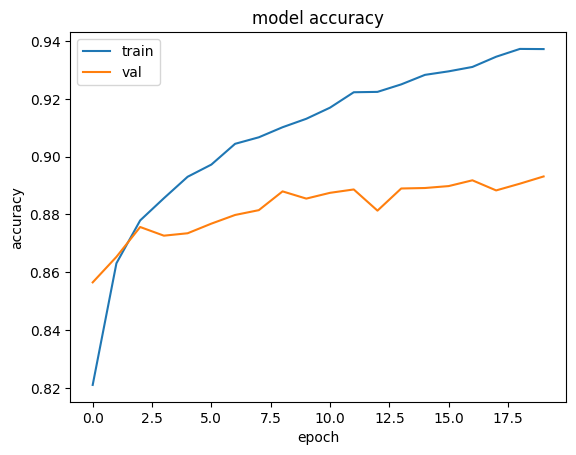

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
4 4


In [ ]:
mnist_train_path = '/content/sample_data/fashion-mnist_train.csv'
mnist_test_path = '/content/sample_data/fashion-mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head())
print(mnist_train.shape)

X_train = mnist_train.iloc[:,1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

# Kết quả output trong hình:
# (60000, 784)
# Number of classes: 10
# Classes: [0 1 2 3 4 5 6 7 8 9]

import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

print(np.argmax(model.predict(X_test)[0]), y_test[0])
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img(
    '/content/sample_data/dress.jpg', color_mode='grayscale', target_size=img_size)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array,(784))
img_array = tf.expand_dims(img,0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
#print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

###1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau

###Đọc tập dữ liệu

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Tải bộ dữ liệu CIFAR10
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Kích thước X_train:", X_train.shape) # Sẽ là (50000, 32, 32, 3)
print("Kích thước y_train:", y_train.shape)
print("Kích thước X_test:", X_test.shape)
print("Kích thước y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Kích thước X_train: (50000, 32, 32, 3)
Kích thước y_train: (50000, 1)
Kích thước X_test: (10000, 32, 32, 3)
Kích thước y_test: (10000, 1)


###Xử lý dữ liệu

In [ ]:
# Chuyển đổi nhãn từ 2D sang 1D (ví dụ: từ (50000, 1) thành (50000,))
y_train = y_train.flatten()
y_test = y_test.flatten()

# Feature scaling: Chuẩn hóa dữ liệu pixel về khoảng [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Dữ liệu sau khi chuẩn hóa đã sẵn sàng.")

Dữ liệu sau khi chuẩn hóa đã sẵn sàng.


###Trực quan hóa dữ liệu

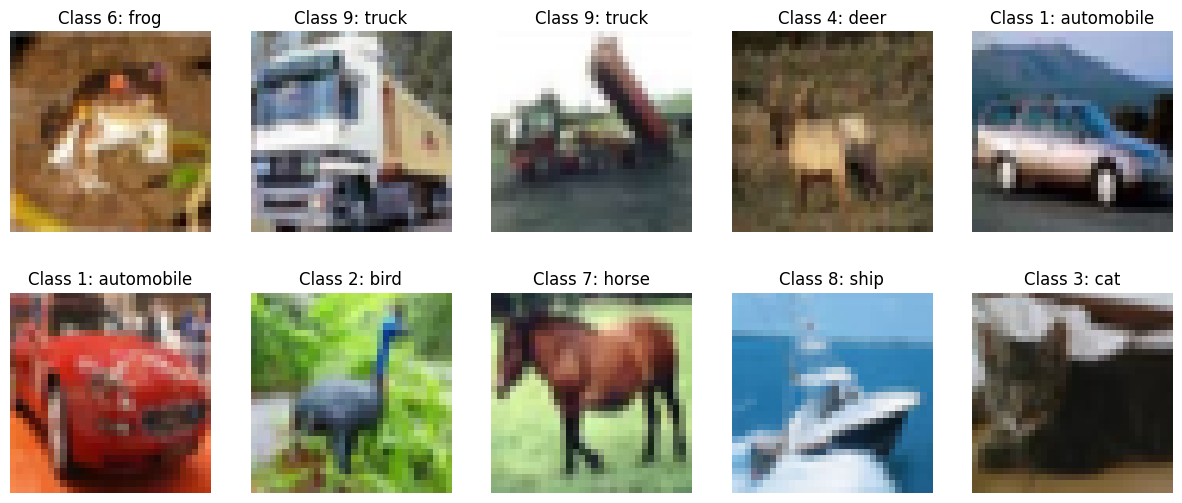

In [ ]:
# Khai báo tên các lớp (class) theo thứ tự từ 0 đến 9
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Cài đặt khung vẽ
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()

# Trực quan hóa 10 ảnh đầu tiên trong tập train
for i in range(10):
    ax[i].imshow(X_train[i])
    # Hiển thị tên nhãn dựa vào giá trị số của y_train[i]
    ax[i].title.set_text(f'Class {y_train[i]}: {class_names[y_train[i]]}')
    ax[i].axis('off') # Ẩn trục tọa độ cho đẹp

plt.subplots_adjust(hspace=0.3)
plt.show()

###Xây dựng mô hình học ANN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Khởi tạo mô hình ANN
ann_model = Sequential()

# Thêm lớp Flatten để chuyển tensor 3D (32, 32, 3) thành vector 1D (3072)
ann_model.add(Flatten(input_shape=(32, 32, 3)))

# Thêm các lớp ẩn (Hidden Layers)
ann_model.add(Dense(units=512, activation='relu'))
ann_model.add(Dense(units=256, activation='relu'))
ann_model.add(Dense(units=128, activation='relu'))

# Lớp đầu ra (Output Layer) với 10 nodes (tương ứng 10 class) dùng hàm softmax
ann_model.add(Dense(units=10, activation='softmax'))

# Cấu hình hàm loss, optimizer và metrics
ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Hiển thị tóm tắt kiến trúc mạng
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

###Huấn luyện ANN model

In [ ]:
# Huấn luyện mô hình, sử dụng 20% dữ liệu train làm validation
model_history = ann_model.fit(X_train, y_train,
                              epochs=30, # Bạn có thể tăng giảm số epoch tùy ý
                              batch_size=64,
                              validation_split=0.2,
                              verbose=1)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3142 - loss: 1.8897 - val_accuracy: 0.3458 - val_loss: 1.8466
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3857 - loss: 1.7050 - val_accuracy: 0.4017 - val_loss: 1.6683
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4207 - loss: 1.6177 - val_accuracy: 0.4175 - val_loss: 1.6272
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4417 - loss: 1.5527 - val_accuracy: 0.4272 - val_loss: 1.6142
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4541 - loss: 1.5221 - val_accuracy: 0.4390 - val_loss: 1.5762
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4716 - loss: 1.4760 - val_accuracy: 0.4528 - val_loss: 1.5250
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4814 - loss: 1.4477 - val_accuracy: 0.4140 - val_loss: 1.6172
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4913 - loss: 1.4182 - 

###Đánh giá model

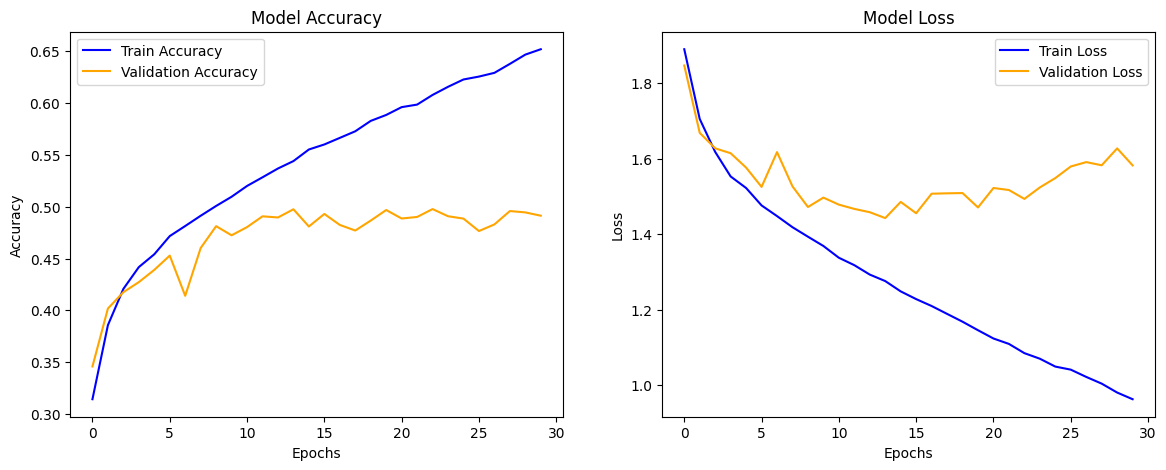


--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
Độ chính xác (Accuracy): 0.4965
Độ mất mát (Loss): 1.5646
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

Ảnh số 10:
- Nhãn thực tế: airplane
- Mô hình dự đoán: ship


In [ ]:
# Vẽ biểu đồ Accuracy và Loss
plt.figure(figsize=(14, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(model_history.history['loss'], label='Train Loss', color='blue')
plt.plot(model_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

# Đánh giá bằng evaluate trên tập Test (dữ liệu chưa từng nhìn thấy)
test_loss, test_acc = ann_model.evaluate(X_test, y_test, verbose=0)
print(f"\n--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
print(f"Độ chính xác (Accuracy): {test_acc:.4f}")
print(f"Độ mất mát (Loss): {test_loss:.4f}")

# (Tùy chọn) In thử 1 dự đoán ngẫu nhiên
sample_idx = 10
pred_probs = ann_model.predict(X_test[sample_idx:sample_idx+1])
predicted_label = np.argmax(pred_probs)
true_label = y_test[sample_idx]

print(f"\nẢnh số {sample_idx}:")
print(f"- Nhãn thực tế: {class_names[true_label]}")
print(f"- Mô hình dự đoán: {class_names[predicted_label]}")

##2. Viết chương trình cài đặt ANN để nhận dạng ảnh chữ viết số trên bộ dataset MNIST do giảng viên cung cấp với các nhãn sau

### Đọc và Tiền xử lý dữ liệu MNIST

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Tải bộ dữ liệu MNIST
mnist = tf.keras.datasets.mnist
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# 2. Chuẩn hóa dữ liệu (Scaling pixel values to [0, 1])
X_train_mnist = X_train_mnist.astype('float32') / 255.0
X_test_mnist = X_test_mnist.astype('float32') / 255.0

print(f"Kích thước tập huấn luyện: {X_train_mnist.shape}")
print(f"Kích thước tập kiểm tra: {X_test_mnist.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập huấn luyện: (60000, 28, 28)
Kích thước tập kiểm tra: (10000, 28, 28)


### Trực quan hóa dữ liệu mẫu

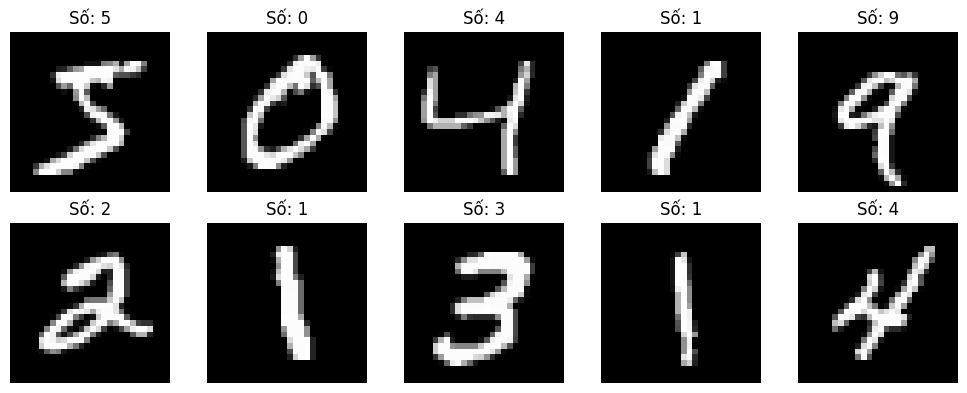

In [6]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train_mnist[i], cmap='gray')
    plt.title(f"Số: {y_train_mnist[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Xây dựng và Huấn luyện mô hình ANN

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Khởi tạo mô hình
mnist_model = Sequential([
    Flatten(input_shape=(28, 28)), # Chuyển ảnh 2D thành vector 1D
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # 10 lớp đầu ra cho các số từ 0-9
])

# Cấu hình mô hình
mnist_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Huấn luyện mô hình
history_mnist = mnist_model.fit(X_train_mnist, y_train_mnist,
                                epochs=10,
                                batch_size=32,
                                validation_split=0.2,
                                verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9205 - loss: 0.2675 - val_accuracy: 0.9566 - val_loss: 0.1456
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9654 - loss: 0.1130 - val_accuracy: 0.9667 - val_loss: 0.1118
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9763 - loss: 0.0774 - val_accuracy: 0.9648 - val_loss: 0.1207
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9808 - loss: 0.0605 - val_accuracy: 0.9723 - val_loss: 0.0947
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0447 - val_accuracy: 0.9714 - val_loss: 0.1004
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9876 - loss: 0.0370 - val_accuracy: 0.9724 - val_loss: 0.1119
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9899 - loss: 0.0308 - val_accuracy: 0.9729 - val_loss: 0.1112
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9909 - loss: 0.0274 - 

### Đánh giá kết quả


Độ chính xác trên tập Test: 0.9789


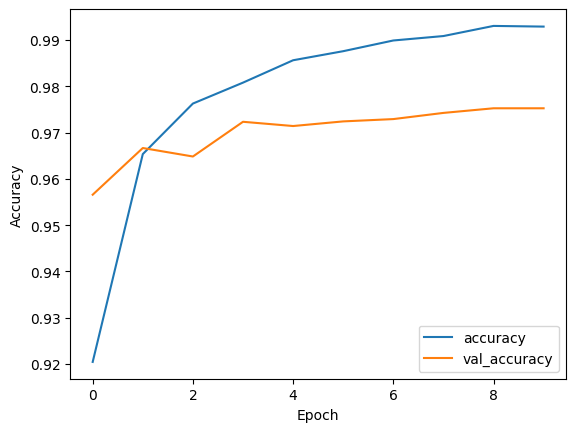

In [8]:
test_loss_m, test_acc_m = mnist_model.evaluate(X_test_mnist, y_test_mnist, verbose=0)
print(f"\nĐộ chính xác trên tập Test: {test_acc_m:.4f}")

# Vẽ biểu đồ loss/accuracy
plt.plot(history_mnist.history['accuracy'], label='accuracy')
plt.plot(history_mnist.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

##3. Cho đoạn mã đọc ảnh của Cat và Dog


### 1. Tải và chuẩn bị dữ liệu Cat vs Dog
Chúng ta sẽ tải một tập dữ liệu nhỏ để minh họa việc đọc ảnh từ thư mục.

In [21]:
!wget --no-check-certificate https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip -O /content/cats_and_dogs.zip

import zipfile
import os

local_zip = '/content/cats_and_dogs.zip'
try:
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall('/content/cats_and_dogs_filtered')
    print("Giải nén thành công dữ liệu dự phòng!")
except Exception as e:
    print(f"Lỗi: {e}. Nếu vẫn gặp lỗi, bạn vui lòng tải file zip thủ công lên Colab.")

--2026-06-01 05:22:15--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.54.42.9, 2600:1407:7400:1187::317f, 2600:1407:7400:1184::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.54.42.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘/content/cats_and_dogs.zip’

/content/cats_and_d 100%[===================>] 786.67M  96.3MB/s    in 11s     

2026-06-01 05:22:26 (72.4 MB/s) - ‘/content/cats_and_dogs.zip’ saved [824887076/824887076]

Giải nén thành công dữ liệu dự phòng!


In [25]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

PATH = '/content/cats_and_dogs_filtered/PetImages'

# --- Bước dọn dẹp file lỗi để tránh UnidentifiedImageError ---
if os.path.exists(PATH):
    print("Đang kiểm tra và dọn dẹp dữ liệu...")
    for folder in ['Cat', 'Dog']:
        folder_path = os.path.join(PATH, folder)
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            # Xóa các file không phải ảnh hoặc file rác hệ thống (như Thumbs.db)
            if not filename.lower().endswith(('.jpg', '.jpeg')):
                os.remove(file_path)
                continue

            # Kiểm tra xem file có thực sự là ảnh JPEG hợp lệ không
            try:
                with open(file_path, 'rb') as f:
                    is_jfif = b'JFIF' in f.peek(10)
                if not is_jfif:
                    os.remove(file_path)
            except Exception:
                os.remove(file_path)
    print("Dọn dẹp hoàn tất.")

if os.path.exists(PATH):
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

    train_generator = datagen.flow_from_directory(
        PATH,
        target_size=(64, 64),
        batch_size=32,
        class_mode='binary',
        subset='training')

    validation_generator = datagen.flow_from_directory(
        PATH,
        target_size=(64, 64),
        batch_size=32,
        class_mode='binary',
        subset='validation')
    print("Dữ liệu sạch đã sẵn sàng!")
else:
    print("Không tìm thấy dữ liệu. Hãy đảm bảo bước tải/giải nén không báo lỗi.")

Đang kiểm tra và dọn dẹp dữ liệu...
Dọn dẹp hoàn tất.
Found 18729 images belonging to 2 classes.
Found 4681 images belonging to 2 classes.
Dữ liệu sạch đã sẵn sàng!


In [16]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Khởi tạo biến để tránh lỗi ở các cell sau
train_generator = None
validation_generator = None

_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'

try:
    # Thử tải dữ liệu
    path_to_zip = tf.keras.utils.get_file('cats_and_dogs_filtered.zip', origin=_URL, extract=True)
    PATH = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')
    print('Tải dữ liệu thành công!')
except Exception as e:
    print(f'Không thể tải dữ liệu tự động: {e}')
    # Kiểm tra nếu người dùng đã upload thủ công
    PATH = '/content/cats_and_dogs_filtered'
    if not os.path.exists(PATH):
        print('Mẹo: Hãy tải file cats_and_dogs_filtered.zip lên Colab, giải nén vào /content/ rồi chạy lại cell này.')

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

if os.path.exists(train_dir):
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary')

    validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary')
else:
    print('Dữ liệu chưa sẵn sàng tại:', PATH)

Không thể tải dữ liệu tự động: URL fetch failure on https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip: 403 -- Forbidden
Mẹo: Hãy tải file cats_and_dogs_filtered.zip lên Colab, giải nén vào /content/ rồi chạy lại cell này.
Dữ liệu chưa sẵn sàng tại: /content/cats_and_dogs_filtered


### 2. Xây dựng mô hình ANN cho ảnh màu

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

cat_dog_model = Sequential([
    Input(shape=(64, 64, 3)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid') # Phân loại nhị phân
])

cat_dog_model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

cat_dog_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,423,553 (24.50 MB)

 Trainable params: 6,423,553 (24.50 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Huấn luyện mô hình

In [23]:
# Huấn luyện mô hình với dữ liệu từ nguồn dự phòng
if 'train_generator' in globals() and train_generator is not None:
    history_cat_dog = cat_dog_model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator
    )
else:
    print('Không tìm thấy dữ liệu huấn luyện. Vui lòng chạy lại ô chuẩn bị dữ liệu.')

Epoch 1/10
 26/625 ━━━━━━━━━━━━━━━━━━━━ 51s 86ms/step - accuracy: 0.5566 - loss: 2.2868

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


456/625 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.5397 - loss: 0.9694

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7e6d043461b0>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py", line 264, in _finite_generator
    yield self._standardize_ba

### 4. Dự đoán thử nghiệm một ảnh mẫu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


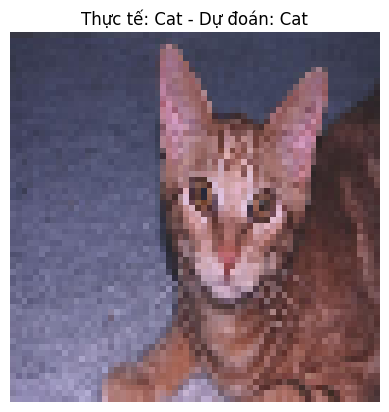

In [24]:
import numpy as np
import matplotlib.pyplot as plt

if 'validation_generator' in globals() and validation_generator is not None:
    # Lấy một lô ảnh ngẫu nhiên để kiểm tra
    x_batch, y_batch = next(validation_generator)
    prediction = cat_dog_model.predict(x_batch)

    plt.imshow(x_batch[0])
    # Mapping nhãn: 0 thường là Cat, 1 thường là Dog
    actual = 'Dog' if y_batch[0] == 1 else 'Cat'
    predicted = 'Dog' if prediction[0] > 0.5 else 'Cat'

    plt.title(f'Thực tế: {actual} - Dự đoán: {predicted}')
    plt.axis('off')
    plt.show()
else:
    print('Generator chưa được khởi tạo.')

##4. Viết chương trình cài đặt ANN để dự báo thu nhập một người > 50K/năm hay <= 50K/năm (nhãn cuối) theo bộ dữ liệu adult do giảng viên cung cấp

### 1. Tải và Tiền xử lý dữ liệu Adult Census Income

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Tải dữ liệu từ UCI Machine Learning Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

df_adult = pd.read_csv(url, names=columns, sep=', ', engine='python')

# Chuyển đổi nhãn mục tiêu sang số (<=50K là 0, >50K là 1)
le = LabelEncoder()
df_adult['income'] = le.fit_transform(df_adult['income'])

# Chuyển đổi các cột phân loại (categorical) sang dạng dummy variables (One-hot encoding)
# Ta bỏ qua 'fnlwgt' vì nó thường không mang lại giá trị dự báo cao
df_final = pd.get_dummies(df_adult.drop(columns=['fnlwgt']), columns=[
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
])

# Chia dữ liệu thành tập features (X) và target (y)
X = df_final.drop('income', axis=1)
y = df_final['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu số
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Kích thước dữ liệu sau khi xử lý: {X_train.shape}")
print(f"Phân bổ lớp thu nhập:\n{df_adult['income'].value_counts(normalize=True)}")

Kích thước dữ liệu sau khi xử lý: (26048, 107)
Phân bổ lớp thu nhập:
income
0    0.75919
1    0.24081
Name: proportion, dtype: float64


### 2. Xây dựng và Huấn luyện mô hình ANN

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

adult_model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Dùng sigmoid cho phân loại nhị phân
])

adult_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

history_adult = adult_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8226 - loss: 0.3814 - val_accuracy: 0.8526 - val_loss: 0.3214
Epoch 2/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8419 - loss: 0.3368 - val_accuracy: 0.8522 - val_loss: 0.3104
Epoch 3/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8462 - loss: 0.3269 - val_accuracy: 0.8557 - val_loss: 0.3066
Epoch 4/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8518 - loss: 0.3183 - val_accuracy: 0.8607 - val_loss: 0.3107
Epoch 5/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8517 - loss: 0.3144 - val_accuracy: 0.8610 - val_loss: 0.3025
Epoch 6/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8537 - loss: 0.3116 - val_accuracy: 0.8637 - val_loss: 0.3010
Epoch 7/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8542 - loss: 0.3085 - val_accuracy: 0.8630 - val_loss: 0.3022
Epoch 8/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8542 - loss: 0.3082 - val_accuracy: 0.8664 - val_

### 3. Đánh giá kết quả dự báo

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8551 - loss: 0.3246

Độ chính xác trên tập kiểm tra: 0.8551


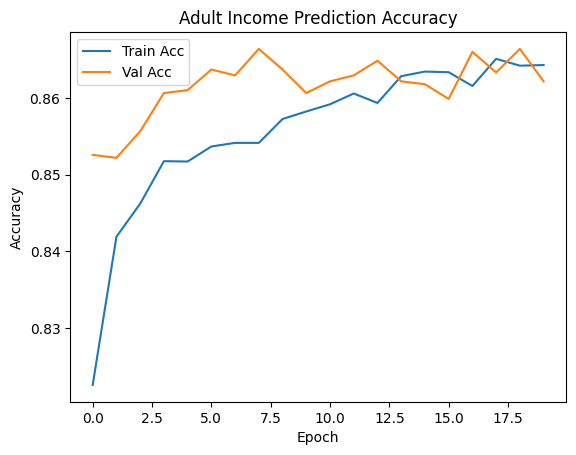

In [28]:
loss, accuracy = adult_model.evaluate(X_test, y_test)
print(f"\nĐộ chính xác trên tập kiểm tra: {accuracy:.4f}")

# Vẽ biểu đồ Accuracy
import matplotlib.pyplot as plt
plt.plot(history_adult.history['accuracy'], label='Train Acc')
plt.plot(history_adult.history['val_accuracy'], label='Val Acc')
plt.title('Adult Income Prediction Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Bài 5: Đánh giá chi tiết mô hình Adult Income
Sử dụng Confusion Matrix và Classification Report để đánh giá chi tiết hiệu suất của mô hình.

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91      4942
        >50K       0.72      0.64      0.68      1571

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513



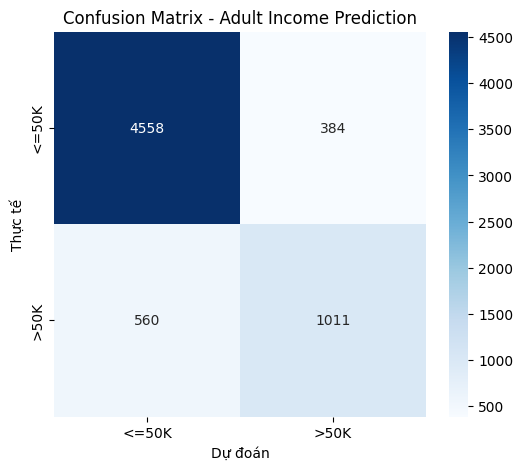

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dự đoán trên tập kiểm tra
y_pred_probs = adult_model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Hiển thị báo cáo phân loại (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# 3. Vẽ Confusion Matrix trực quan
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix - Adult Income Prediction')
plt.show()

### Bài 5: Đánh giá chi tiết mô hình Adult Income
Sử dụng Confusion Matrix và Classification Report để đánh giá chi tiết hiệu suất của mô hình.

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91      4942
        >50K       0.72      0.64      0.68      1571

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513



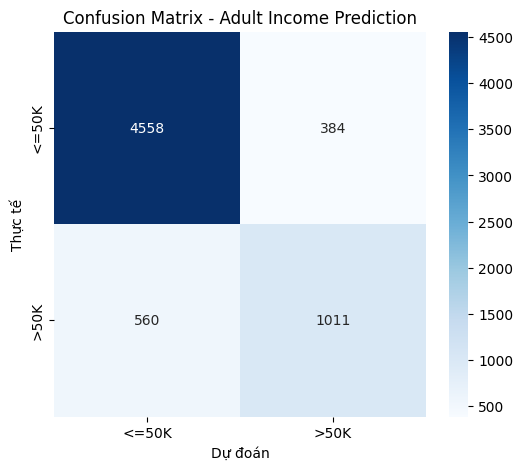

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dự đoán trên tập kiểm tra
y_pred_probs = adult_model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Hiển thị báo cáo phân loại (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# 3. Vẽ Confusion Matrix trực quan
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix - Adult Income Prediction')
plt.show()

### Bài 5: Đánh giá chi tiết mô hình Adult Income
Sử dụng Confusion Matrix và Classification Report để đánh giá sai số của mô hình.

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91      4942
        >50K       0.72      0.64      0.68      1571

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513



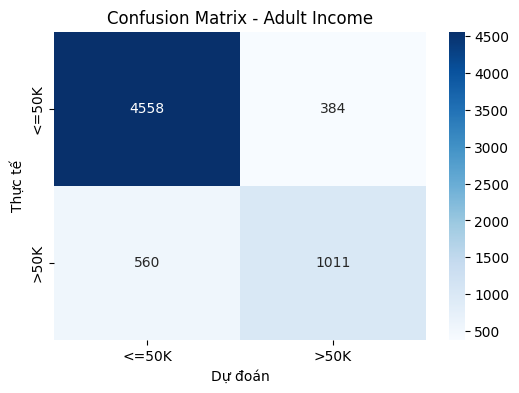

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Dự đoán trên tập kiểm tra
y_pred_probs = adult_model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# Hiển thị báo cáo phân loại
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix - Adult Income')
plt.show()

### Bài 6: Tối ưu hóa mô hình ANN (Model Tuning)
Chúng ta sẽ thử nghiệm một kiến trúc mạng sâu hơn và điều chỉnh tham số để cải thiện kết quả.

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Xây dựng mô hình tối ưu hơn
tuned_model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

tuned_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

# Huấn luyện với số epoch nhiều hơn
history_tuned = tuned_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Đánh giá lại trên tập test
loss_t, acc_t = tuned_model.evaluate(X_test, y_test)
print(f"\nĐộ chính xác sau khi tối ưu: {acc_t:.4f}")

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


652/652 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8139 - loss: 0.3953 - val_accuracy: 0.8418 - val_loss: 0.3412
Epoch 2/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8342 - loss: 0.3505 - val_accuracy: 0.8480 - val_loss: 0.3291
Epoch 3/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8387 - loss: 0.3426 - val_accuracy: 0.8518 - val_loss: 0.3279
Epoch 4/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8416 - loss: 0.3354 - val_accuracy: 0.8486 - val_loss: 0.3208
Epoch 5/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8457 - loss: 0.3271 - val_accuracy: 0.8518 - val_loss: 0.3180
Epoch 6/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8461 - loss: 0.3268 - val_accuracy: 0.8570 - val_loss: 0.3175
Epoch 7/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8492 - loss: 0.3234 - val_accuracy: 0.8530 - val_loss: 0.3134
Epoch 8/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8496 - loss: 0.3192 - val_accuracy: 0.8541 - val_

##5. Viết chương trình cài đặt ANN để dự báo việc đánh giá chất lượng xe ô tô (nhãn cuối) từ bộ dữ liệu car do giảng viên cung cấp.

### 1. Tải và Tiền xử lý dữ liệu Car Evaluation

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Tải dữ liệu Car Evaluation từ UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df_car = pd.read_csv(url, names=columns)

# Mã hóa các biến phân loại đầu vào thành số
# Vì các biến này có tính thứ tự (ordinal), ta có thể dùng LabelEncoder hoặc map thủ công
le = LabelEncoder()
for col in df_car.columns:
    df_car[col] = le.fit_transform(df_car[col])

# Chia features và target
X_car = df_car.drop('class', axis=1)
y_car = df_car['class']

# Chia tập huấn luyện và kiểm tra
X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(X_car, y_car, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu
scaler_car = StandardScaler()
X_train_car = scaler_car.fit_transform(X_train_car)
X_test_car = scaler_car.transform(X_test_car)

print(f"Số lượng mẫu huấn luyện: {X_train_car.shape[0]}")
print(f"Số lượng đặc trưng: {X_train_car.shape[1]}")
print(f"Các lớp mục tiêu: {np.unique(y_car)}")

Số lượng mẫu huấn luyện: 1382
Số lượng đặc trưng: 6
Các lớp mục tiêu: [0 1 2 3]


### 2. Xây dựng và Huấn luyện mô hình ANN cho Car Evaluation

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Khởi tạo mô hình ANN
car_model = Sequential([
    Dense(64, activation='relu', input_dim=X_train_car.shape[1]),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='softmax') # Có 4 lớp chất lượng xe
])

# Compile mô hình
car_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Huấn luyện
history_car = car_model.fit(
    X_train_car, y_train_car,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5374 - loss: 1.1431 - val_accuracy: 0.6259 - val_loss: 0.8526
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7257 - loss: 0.6725 - val_accuracy: 0.7194 - val_loss: 0.7090
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7852 - loss: 0.5465 - val_accuracy: 0.7482 - val_loss: 0.5919
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8278 - loss: 0.4293 - val_accuracy: 0.7698 - val_loss: 0.5010
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8496 - loss: 0.3552 - val_accuracy: 0.7770 - val_loss: 0.4468
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 0.3118 - val_accuracy: 0.8201 - val_loss: 0.4108
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8954 - loss: 0.2730 - val_accuracy: 0.8345 - val_loss: 0.3724
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8970 - loss: 0.2481 - val_accuracy: 0.8417 - val_loss: 0.3523
Epo

### 3. Đánh giá mô hình Car Evaluation

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9798 - loss: 0.0611 

Độ chính xác trên tập kiểm tra: 0.9798


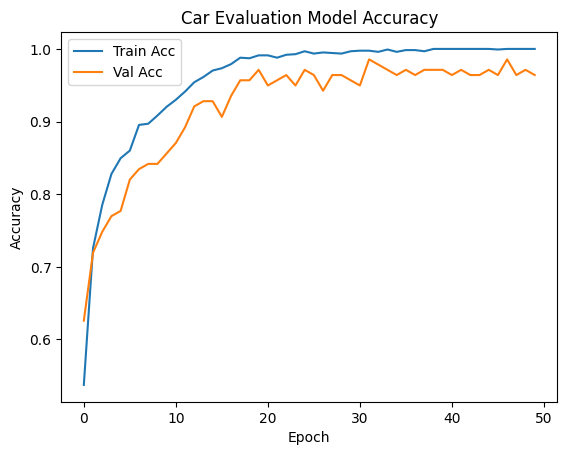

In [35]:
loss_car, acc_car = car_model.evaluate(X_test_car, y_test_car)
print(f"\nĐộ chính xác trên tập kiểm tra: {acc_car:.4f}")

# Trực quan hóa quá trình học
import matplotlib.pyplot as plt
plt.plot(history_car.history['accuracy'], label='Train Acc')
plt.plot(history_car.history['val_accuracy'], label='Val Acc')
plt.title('Car Evaluation Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()